### **Exercise 6.10:** 

Consider the equation $x=1-e^{cx}$, where $c$ is a known parameter and $x$ is unknown. This equation arises in variety of situations, including the physics of contact processes, mathematical models of epidemics and theory of random graphs.

a) Write a program to solve this equation for $x$ using the relaxation method for the case $c = 2$. Calculate your solution to an accuracy of at least $10^{-6}$.

b) Modify your program to calculate the solution for values of $c$ from $0$ to $3$ insteps of $0.01$ and make a plot of $x$ as a function of $c$. You should see a clear transition from a regime in which $x = 0$ to a regime of nonzero $x$. This is another example of a phase transition. In physics this transition is known as the *percolation transition*; in epidemiology it is the *epidemic threshold*.

a) The equation $x=1-e^{cx}$ is in simple form. For the error, we have $\epsilon' \simeq \frac{x-x'}{1-\frac{1}{f'(x)}} = \frac{x-x'}{1-\frac{1}{ce^{-cx}}}$.

In [8]:
from math import exp

# Constants 
c = 2 
accuracy = 10 ** -6

# Initial value
x1 = 0.5 
iterations = 0

# Loop until error is small enough 
while True:
    x2 = 1 - exp(-c * x1)
    iterations += 1

    error = abs((x1 - x2) / (1 - 1 / (c * exp(-c * x1))))
    
    if error <= accuracy:
        break
    
    x1 = x2
    
print(f"Solution: {x1}, Error: {error}, Iterations: {iterations}")

Solution: 0.7968102799464087, Error: 7.518287668643491e-07, Iterations: 15


b)

/var/folders/nx/wmvq8vjn5qq3k8wb_rb_89540000gn/T/ipykernel_780/614156801.py:24: RuntimeWarning: divide by zero encountered in scalar divide
  error = abs((x1 - x2) / (1 - 1 / (c * exp(-c * x1))))


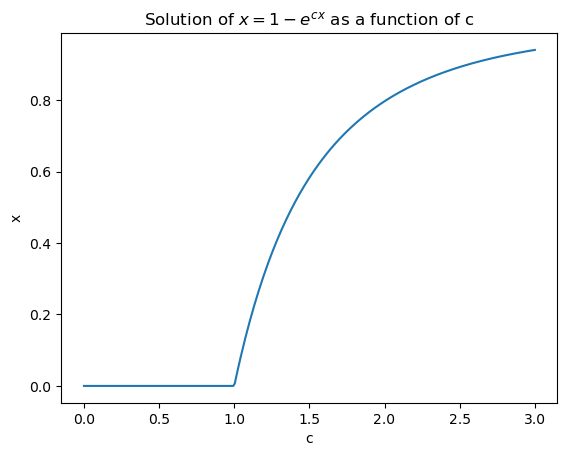

In [9]:
from math import exp
from numpy import linspace
from pylab import plot,show,xlabel,ylabel,title

# Constants 
c_values = linspace(0, 3, 300) # array of c in [0, 3] in steps of 0.01
accuracy = 10 ** -6

# Empty list for x_values
x_values = []

# c loop 
for c in c_values:
    
    # Initial value
    x1 = 0.5
    iterations = 0

    # Loop until error is small enough 
    while True:
        x2 = 1 - exp(-c * x1)
        iterations += 1
    
        error = abs((x1 - x2) / (1 - 1 / (c * exp(-c * x1))))
        
        if error <= accuracy:
            break
        
        x1 = x2
        
    # print(f"c: {c}, Solution: {x1}, Error: {error}, Iterations: {iterations}")
    x_values.append(x2)

# Make the graph 
plot(c_values,x_values) 
title("Solution of $x = 1 - e^{cx}$ as a function of c")
xlabel("c") 
ylabel("x") 
show()